# Convolutional neural network from scratch

In this notebook, I implement a CNN without using any deep learning frameworks and train it on the MNIST handwritten digits dataset.

In [17]:
import numpy as np
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import itertools

## Simple convolution demo
This is a demonstration of convolving a single 2d input matrix with a single 2d kernel, then backpropagating. When I add channels, batches, strides, etc. later on, the implementation becomes much more complicated, but the basic process is the same.

In [18]:
X = np.arange(1, 10).reshape(3, 3)
W = np.arange(10, 14).reshape(2, 2)
dloss = np.arange(14, 18).reshape(2, 2)
b = 1

print("X:")
print(X)
print()
print("W:")
print(W)
print()
print("dloss:")
print(dloss)
print()
print("b:")
print(b)

X:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

W:
[[10 11]
 [12 13]]

dloss:
[[14 15]
 [16 17]]

b:
1


### Regular convolution
There are two ways to implement convolutions:
1. Directly perform a convolution with a sliding window
2. Convert the kernel into a doubly block Toeplitz matrix, flatten the input matrix into a vector, and multiply them together, as explained in [this article](https://www.baeldung.com/cs/convolution-matrix-multiplication)

I demonstrate both options here and use the first approach in my main implementation.

In [19]:
def convolve_2d_direct(X, W, b=0):
    windows = np.lib.stride_tricks.sliding_window_view(X, W.shape)
    return np.einsum("jkrs,rs->jk", windows, W) + b

print("Direct convolution:")
print(convolve_2d_direct(X, W, b))


Direct convolution:
[[146 192]
 [284 330]]


The logic for building the Toeplitz matrix depends on what kind of convolution you are doing. Signal processing-style convolutions (full padding, flipped kernel) and machine learning-style convolutions (no padding, no flipping) require different Toeplitz matrices. In this case, I'm using machine learning-style convolutions.

In [20]:
def build_toeplitz(r, num_rows):
    zero_block = np.zeros(r[0].shape)
    blocks = [
        [*itertools.repeat(zero_block, i), *r, *itertools.repeat(zero_block, num_rows - i - 1)]
        for i in range(num_rows)
    ]
    toeplitz = np.block(blocks)
    return toeplitz

width_Z = X.shape[1] - W.shape[1] + 1
height_Z = X.shape[0] - W.shape[0] + 1
toeplitz_blocks = [build_toeplitz(W_row, width_Z) for W_row in W]
doubly_block_toeplitz = build_toeplitz(toeplitz_blocks, width_Z)

print("Doubly block Toeplitz matrix:")
print(doubly_block_toeplitz)

Doubly block Toeplitz matrix:
[[10. 11.  0. 12. 13.  0.  0.  0.  0.]
 [ 0. 10. 11.  0. 12. 13.  0.  0.  0.]
 [ 0.  0.  0. 10. 11.  0. 12. 13.  0.]
 [ 0.  0.  0.  0. 10. 11.  0. 12. 13.]]


In [21]:
def convolve_2d_toeplitz(X, doubly_block_toeplitz, b=0):
    flattened_X = X.flatten()
    flattened_Z = doubly_block_toeplitz @ flattened_X + b
    Z = flattened_Z.reshape(height_Z, width_Z)
    return Z

print("Convolution with Toeplitz matrix:")
print(convolve_2d_toeplitz(X, doubly_block_toeplitz, b))

Convolution with Toeplitz matrix:
[[146. 192.]
 [284. 330.]]


### Transposed convolution
For backpropagation, we need to use a transposed convolution. There are three ways to implement this:
1. Directly perform a transposed convolution
2. Do a regular convolution with full padding and a flipped kernel
3. Transpose the doubly block Toeplitz matrix we built before, flatten dloss, and multiply them together

I demonstrate all three options here and use the second approach in my main implementation.

In [22]:
def transposed_convolve_2d_direct(dloss, W):
    height_Z = dloss.shape[0]
    width_Z = dloss.shape[1]
    height_W = W.shape[0]
    width_W = W.shape[1]
    height_X = height_Z + height_W - 1
    width_X = width_Z + width_W - 1
    dloss_dX = np.zeros((height_X, width_X))
    for i in range(height_Z):
        for j in range(width_Z):
            dloss_dX[i : i + height_W, j : j + width_W] += dloss[i, j] * W
    return dloss_dX

print("Direct transposed convolution:")
print(transposed_convolve_2d_direct(dloss, W))

Direct transposed convolution:
[[140. 304. 165.]
 [328. 708. 382.]
 [192. 412. 221.]]


In [23]:
def transposed_convolve_2d_regular(dloss, W):
    W = np.flip(W)
    pad_width = W.shape[0] - 1
    pad_height = W.shape[1] - 1
    dloss = np.pad(dloss, ((pad_width, pad_width), (pad_height, pad_height)), mode="constant")
    dloss_dX = convolve_2d_direct(dloss, W)
    return dloss_dX

print("Transposed convolution using regular convolution:")
print(transposed_convolve_2d_regular(dloss, W))

Transposed convolution using regular convolution:
[[140 304 165]
 [328 708 382]
 [192 412 221]]


In [24]:
height_X = X.shape[0]
width_X = X.shape[1]

def transposed_convolve_2d_toeplitz(dloss, doubly_block_toeplitz):
    flattened_dloss_dZ = dloss.flatten()
    flattened_dloss_dX = doubly_block_toeplitz.transpose() @ flattened_dloss_dZ
    dloss_dX = flattened_dloss_dX.reshape(height_X, width_X)
    return dloss_dX

print("Transposed convolution with Toeplitz matrix:")
print(transposed_convolve_2d_toeplitz(dloss, doubly_block_toeplitz))

Transposed convolution with Toeplitz matrix:
[[140. 304. 165.]
 [328. 708. 382.]
 [192. 412. 221.]]


### Simple convolution layer

In [25]:
class Conv2dSimple:
    def __init__(self, kernel_size):
        rng = np.random.default_rng()
        self.W = rng.normal(size=(kernel_size, kernel_size), scale=0.01)
        self.b = rng.normal(size=1, scale=0.01)

    def forward(self, X):
        self.X = X
        return convolve_2d_direct(X, self.W, self.b)

    def backward(self, dloss, learning_rate):
        dloss_dW = convolve_2d_direct(X, dloss)
        dloss_db = dloss.sum()
        dloss_dX = transposed_convolve_2d_direct(dloss, self.W)

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss_dX

In [26]:
conv = Conv2dSimple(kernel_size=2)
print("X:")
print(X)
print()
print("W:")
print(conv.W)
print()
print("b:")
print(conv.b)
print()
print("dloss:")
print(dloss)

X:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

W:
[[ 0.00060124 -0.00548545]
 [-0.02009299 -0.00540746]]

b:
[0.00741898]

dloss:
[[14 15]
 [16 17]]


In [27]:
Z = conv.forward(X)
print("Z:")
print(Z)

Z:
[[-0.1103599  -0.14074456]
 [-0.20151386 -0.23189851]]


In [28]:
dloss_dX = conv.backward(dloss, learning_rate=0.01)
print("dloss_dX:")
print(dloss_dX)
print()
print("W after update:")
print(conv.W)
print()
print("b after update:")
print(conv.b)

dloss_dX:
[[ 0.00841731 -0.06777771 -0.0822817 ]
 [-0.27168201 -0.4546453  -0.17436444]
 [-0.32148776 -0.42810005 -0.09192676]]

W after update:
[[-1.92939876 -2.55548545]
 [-3.81009299 -4.41540746]]

b after update:
[-0.61258102]


## Main implementation

### Load data

In [29]:
rng = np.random.default_rng()

def shuffle_in_unison(*arrays):
    p = rng.permutation(arrays[0].shape[0])
    return [array[p] for array in arrays]

class DataLoader:
    def __init__(self, X, y, batch_size, shuffle=True):
        self.length = X.shape[0]
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.i = 0
        if shuffle:
            self.X, self.y = shuffle_in_unison(X, y)
        else:
            self.X = X
            self.y = y

    def __iter__(self):
        return self
    
    def __next__(self):
        if self.i < self.length:
            batch = (self.X[self.i : self.i + batch_size], self.y[self.i : self.i + batch_size])
            self.i += batch_size
            return batch
        else:
            self.i = 0 # Reset iterator after exhausting all elements
            if self.shuffle:
                self.X, self.y = shuffle_in_unison(self.X, self.y)
            raise StopIteration

def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

train_dataset = MNIST(root="./data", train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root="./data", train=False, download=True, transform=ToTensor())

X_train = np.expand_dims(train_dataset.data.numpy(), axis=1)
y_train = train_dataset.targets.numpy()
X_test = np.expand_dims(test_dataset.data.numpy(), axis=1)
y_test = test_dataset.targets.numpy()

num_classes = len(train_dataset.classes)

batch_size = 32

train_loader = DataLoader(X_train, y_train, batch_size, shuffle=True)
test_loader = DataLoader(X_test, y_test, batch_size, shuffle=True)

print(f"Shape of each image: {X_train.shape[1:]}")
print(f"Size of training set: {X_train.shape[0]}")
print(f"Size of testing set: {X_test.shape[0]}")

Shape of each image: (1, 28, 28)
Size of training set: 60000
Size of testing set: 10000


### Sample data points

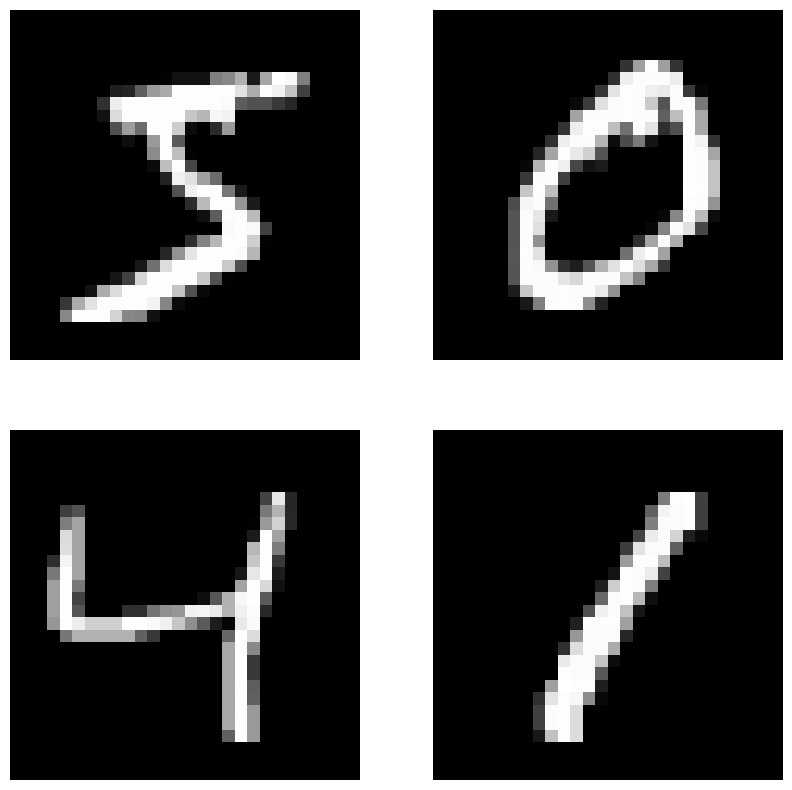

In [30]:
rows = 2
columns = 2
fig, axs = plt.subplots(rows, columns, figsize=(10, 10))
for i in range(rows):
    for j in range(columns):
        axs[i, j].imshow(X_train[2 * i + j].reshape(28, 28), cmap="gray")
        axs[i, j].axis("off")
plt.show()

### Loss function

In [31]:
def log_sum_exp(z):
    # z should be a vector of logits or a batch of vectors of logits.

    c = z.max(axis=-1, keepdims=True)
    # Add and subtract the max value of z for numerical stability
    return (c + np.log(np.sum(np.exp(z - c), axis=-1, keepdims=True))).flatten()

def cross_entropy_loss(y_pred_logits, y_true):
    # y_pred_logits should contain logits, NOT probabilities
    # y_true should be an integer or a batch of integers
    if isinstance(y_true, np.ndarray): # y_true is a batch
        return -y_pred_logits[np.arange(y_true.shape[0]), y_true] + log_sum_exp(y_pred_logits)
    else: # y_true is an integer
        return -y_pred_logits[y_true] + log_sum_exp(y_pred_logits)

### Convolution

In [32]:
class Conv2d:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias

        rng = np.random.default_rng()

        self.W = rng.normal(size=(out_channels, in_channels, kernel_size, kernel_size), scale=0.01)
        self.b = rng.normal(size=out_channels, scale=0.01)

    def forward(self, X):
        self.X = np.pad(X, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode="constant")
        Z = self.__convolve()
        return Z

    def backward(self, dloss, learning_rate):
        self.dilated_dloss = self.__dilate(dloss, self.stride, axes=(2, 3))

        self.leftover_height = (self.X.shape[2] - self.kernel_size) % self.stride
        self.leftover_width = (self.X.shape[3] - self.kernel_size) % self.stride

        dloss_dX = self.__calc_dloss_dX()
        dloss_dW = self.__calc_dloss_dW()
        if self.bias:
            dloss_db = self.__calc_dloss_db()

        self.W -= learning_rate * dloss_dW
        if self.bias:
            self.b -= learning_rate * dloss_db

        return dloss_dX

    def __convolve(self):
        # Cross-correlate X with W and add b
        windows_X = np.lib.stride_tricks.sliding_window_view(self.X, self.W.shape[1:], axis=(1, 2, 3))[:, ::self.stride, ::self.stride, ::self.stride]
        Z = np.einsum("bijkqrs,fqrs->bfjk", windows_X, self.W)
        if self.bias:
            Z += self.b.reshape(-1, 1, 1)
        return Z

    def __dilate(self, A, stride=1, axes=None):
        # Add zeroes inside array A so we can do fractionally strided convolutions
        if axes is None:
            axes = range(A.ndim)
        for i in axes:
            A = np.insert(A, np.repeat(np.arange(1, A.shape[i]), stride - 1), 0, axis=i)
        return A
    
    def __calc_dloss_dX(self):
        # Do a transposed convolution between dloss and W
        transpose_padding = self.kernel_size - self.padding - 1
        padded_dilated_dloss = np.pad(self.dilated_dloss, ((0, 0), (0, 0), (transpose_padding, transpose_padding), (transpose_padding, transpose_padding)), mode="constant")
        flipped_W = np.flip(self.W, axis=(2, 3))
        windows_dloss = np.lib.stride_tricks.sliding_window_view(padded_dilated_dloss, (flipped_W.shape[0], flipped_W.shape[2], flipped_W.shape[3]), axis=(1, 2, 3))
        dloss_dX = np.einsum("bijkfrs,fqrs->bqjk", windows_dloss, flipped_W)
        # Zero-pad rows and columns the kernel never reached during the forward pass
        padded_dloss_dX = np.pad(dloss_dX, ((0, 0), (0, 0), (0, self.leftover_height), (0, self.leftover_width)), mode="constant")
        return padded_dloss_dX
    
    def __calc_dloss_dW(self):
        # Cross-correlate X with dloss
        # Remove rows and columns the kernel never reached during the forward pass
        trimmed_X = self.X[:, :, : self.X.shape[2] - self.leftover_height, : self.X.shape[3] - self.leftover_width]
        windows_X = np.lib.stride_tricks.sliding_window_view(trimmed_X, self.dilated_dloss.shape[2:], axis=(2, 3))
        dloss_dW = np.einsum("bijkrs,bfrs->fijk", windows_X, self.dilated_dloss)
        return dloss_dW

    def __calc_dloss_db(self):
        # Sum over dloss
        dloss_db = self.dilated_dloss.sum(axis=(0, 2, 3))
        return dloss_db

### Max pooling

In [33]:
class MaxPool2d:
    def __init__(self, kernel_size):
        self.kernel_size = kernel_size
        self.stride = kernel_size

    def forward(self, X):
        self.X = X
        self.windows_X = np.lib.stride_tricks.sliding_window_view(X, (self.kernel_size, self.kernel_size), axis=(2, 3))[:, :, ::self.stride, ::self.stride]
        return self.windows_X.max(axis=(-1, -2))

    def backward(self, dloss, learning_rate):
        # Find argmax for each window of X
        flattened_windows_X = self.windows_X.reshape(-1, self.windows_X.shape[-1] * self.windows_X.shape[-2])
        argmaxes = flattened_windows_X.argmax(axis=1)

        # Create an array of zeroes and fill the argmax locations with 1
        mask = np.zeros(flattened_windows_X.shape)
        mask[np.arange(mask.shape[0]), argmaxes] = 1

        # Multiply each 1 in the mask with the corresponding dloss
        windows_flattened_dloss_dX = np.einsum("i,ij->ij", dloss.flatten(), mask)

        # Reshape derivatives into the same shape as X
        windows_dloss_dX = windows_flattened_dloss_dX.reshape(self.windows_X.shape)
        dloss_dX = self.__reassemble_windows(windows_dloss_dX)
        return dloss_dX

    def __reassemble_windows(self, windows):
        # Reconstruct original array from sliding windows.
        # Assumes original array has shape (N, C, H, W) and stride == kernel_size.

        a = np.moveaxis(windows, (0, 1, 2, 3), (2, 3, 1, 0))
        b = np.concatenate(a, axis=4)
        c = np.concatenate(b, axis=2)

        # If the kernel does not perfectly divide the input,
        # then some values on the right and bottom edges of the input matrix
        # will never be reached during the forward pass. We need to pad our
        # reconstructed array with zeroes to account for this.
        leftover_width = self.X.shape[3] % self.kernel_size
        leftover_height = self.X.shape[2] % self.kernel_size
        d = np.pad(c, ((0, 0), (0, 0), (0, leftover_height), (0, leftover_width)), mode="constant")
        return d

### Flatten

In [34]:
class Flatten:
    def forward(self, X):
        self.shape = X.shape
        # Keep batch size and flatten all the other dimensions
        return X.reshape(X.shape[0], -1)

    def backward(self, dloss, learning_rate):
        return dloss.reshape(self.shape)

### Linear

In [35]:
class Linear:
    def __init__(self, input_size, output_size):
        rng = np.random.default_rng()

        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.normal(size=(input_size, output_size), scale=0.01)
        self.b = rng.normal(size=output_size, scale=0.01)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = self.input # Implicit Jacobian

        # Calculate outer product of each vector in dW
        # with each corresponding vector in dloss
        dloss_dW = np.einsum("ij,ik->ijk", dW, dloss)

        db = 1 # Implicit Jacobian
        dloss_db = db * dloss

        # Merge all gradients in batch
        dloss_dW = dloss_dW.sum(axis=0)
        dloss_db = dloss_db.sum(axis=0)

        dloss = np.matvec(self.W, dloss)

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

### ReLU

In [36]:
class ReLU:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = (self.output > 0).astype("float") # Implicit Jacobian
        return drelu * dloss

### Softmax

In [37]:
class Softmax:
    def forward(self, x):
        # Subtract the max value of x for numerical stability
        shifted_x = x - x.max(axis=-1, keepdims=True)
        exp_logits = np.exp(shifted_x)
        return exp_logits / exp_logits.sum(axis=-1, keepdims=True)

    # A backward function isn't needed here since we calculate the
    # derivative of softmax in ConvolutionalNeuralNetwork's backward method.

### Convolutional neural network

In [38]:
class ConvolutionalNeuralNetwork:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        y_pred_logits = X
        softmax = Softmax()
        y_pred_probs = softmax.forward(X)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred_probs, y_true, learning_rate):
        batch_size = y_pred_probs.shape[0]
        y_true_one_hot = one_hot_encode(y_true, num_classes)

        # Combined derivative of both cross entropy and softmax
        dloss = (y_pred_probs - y_true_one_hot) / batch_size

        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)

### Train and test model

In [39]:
# Each image has shape 1 x 28 x 28. I use comments here to indicate the shape of the image
# after each layer as N x C x H x W:
# N: batch size
# C: number of channels
# H: height in pixels
# W: width in pixels
model = ConvolutionalNeuralNetwork([
    Conv2d(in_channels=1, out_channels=3, kernel_size=5, stride=2, padding=0), # N x 3 x 12 x 12
    ReLU(), # N x 3 x 12 x 12
    Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1), # N x 3 x 12 x 12
    MaxPool2d(2), # N x 3 x 6 x 6
    Flatten(), # N x 108
    Linear(108, 30), # N x 30
    ReLU(), # N x 30
    Linear(30, 10), # N x 10
])

epochs = 2

def train(model):
    loss = 0
    correct = 0
    for x, y in train_loader:
        y_pred_logits, y_pred_probs = model.forward(x)
        loss += cross_entropy_loss(y_pred_logits, y).sum()
        classifications = y_pred_probs.argmax(axis=-1)
        correct += (classifications == y).sum()
        model.backward(y_pred_probs, y, learning_rate=0.01)
    train_loss = loss / len(X_train)
    train_accuracy = correct / len(X_train)
    return train_loss, train_accuracy

def test(model):
    loss = 0
    correct = 0
    for x, y in test_loader:
        y_pred_logits, y_pred_probs = model.forward(x)
        loss += cross_entropy_loss(y_pred_logits, y).sum()
        classifications = y_pred_probs.argmax(axis=-1)
        correct += (classifications == y).sum()
    test_loss = loss / len(X_test)
    test_accuracy = correct / len(X_test)
    return test_loss, test_accuracy

def train_and_test(model, epochs):
    for epoch in range(epochs):
        train_loss, train_accuracy = train(model)
        test_loss, test_accuracy = test(model)
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Training loss: {train_loss:.2f}")
        print(f"Training accuracy: {train_accuracy:.0%}")
        print(f"Testing loss: {test_loss:.2f}")
        print(f"Testing accuracy: {test_accuracy:.0%}")
        print()

train_and_test(model, epochs)

Epoch 1/2
Training loss: 0.68
Training accuracy: 76%
Testing loss: 0.14
Testing accuracy: 96%

Epoch 2/2
Training loss: 0.14
Training accuracy: 96%
Testing loss: 0.11
Testing accuracy: 96%



### Sources:
- https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md
- https://arxiv.org/pdf/1603.07285
- https://www.deeplearningbook.org/contents/convnets.html
- https://medium.com/@mayank.utexas/backpropagation-for-convolution-with-strides-8137e4fc2710
- https://deeplearning.cs.cmu.edu/F21/document/recitation/Recitation5/CNN_Backprop_Recitation_5_F21.pdf
- https://www.youtube.com/watch?v=Lakz2MoHy6o
- https://colab.research.google.com/github/pythonandml/dlbook/blob/master/content/convolutional_neural_networks/cnn_from_scratch.ipynb#scrollTo=b5c5f5cd-eea7-4208-b091-a2a29668fd80
- https://petewarden.com/2015/04/20/why-gemm-is-at-the-heart-of-deep-learning/
- https://github.com/alisaaalehi/convolution_as_multiplication/blob/main/ConvAsMulExplained.pdf
- https://www.baeldung.com/cs/convolution-matrix-multiplication
- https://www.cs.uoi.gr/~cnikou/Courses/Digital_Image_Processing/Chapter_04c_Frequency_Filtering_(Circulant_Matrices).pdf
- https://iq.opengenus.org/im2col/
- https://leimao.github.io/blog/Convolution-Transposed-Convolution-As-Matrix-Multiplication/
- https://medium.com/@rmwkwok/explain-implement-and-compare-2d-transposed-convolution-in-numpy-tensorflow-and-pytorch-2068d986ec5
- https://www.youtube.com/watch?v=qb4nRoEAASA
- https://genn-team.github.io/posts/sw_blog_toeplitz.html

